# Production Pipeline with PanelPipeline

**Module**: Production & Deployment | **Notebook 03**  
**Level**: Intermediate  
**Duration**: 60-90 minutes

---

## Learning Objectives

1. Use `PanelPipeline` for end-to-end model deployment
2. Configure pipelines for different model types (Static, GMM)
3. Use `forecast()` for multi-step ahead predictions (GMM)
4. Re-estimate models with updated data using `refit()`
5. Compare old vs new model versions
6. Export pipeline configuration for documentation

## Prerequisites

- Completed Notebooks 01 (Predict Fundamentals) and 02 (Save/Load Models)
- Familiarity with panel data models (Fixed Effects, GMM)
- Basic understanding of model deployment concepts

## Setup

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# PanelBox imports
from panelbox.gmm import DifferenceGMM
from panelbox.models.static.fixed_effects import FixedEffects
from panelbox.production import PanelPipeline

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"

# Create directories
for d in [FIGURES_DIR, MODELS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


## Section 1: The Production Challenge

In **research**, we estimate a model once, analyze the results, and write about our findings. The workflow is linear and self-contained.

In **production**, the workflow is fundamentally different:
- **Estimate periodically** — models are re-trained monthly or quarterly with fresh data
- **Predict daily** — scoring new observations as they arrive
- **Monitor quality** — checking if the model still performs well or has degraded

We need a **standardized workflow** that encapsulates the full model lifecycle:

```
[Training Data] → [fit()] → [validate()] → [save()] → [Production]
                                                           ↓
[New Data] → [load()] → [predict()] → [Predictions] → [Business Logic]
                                                           ↓
[Updated Data] → [refit()] → [compare()] → [save(v2)] → [Updated Production]
```

PanelBox's `PanelPipeline` class provides exactly this — a single object that wraps model specification, estimation, prediction, persistence, and validation.

### Load the Datasets

We'll use two datasets throughout this notebook:

1. **Firm panel** — 100 firms over 20 years, for static models
2. **Bank LGD panel** — 200 loan contracts over 15 months, for GMM models

In [2]:
# Firm panel data
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")
df_new_firms = pd.read_csv(DATA_DIR / "new_firms.csv")

print("=== Firm Panel ===")
print(f"Shape: {df_firms.shape}")
print(
    f"Firms: {df_firms['firm_id'].nunique()}, Years: {df_firms['year'].min()}-{df_firms['year'].max()}"
)
display(df_firms.head())

=== Firm Panel ===
Shape: (2000, 7)
Firms: 100, Years: 2000-2019


,firm_id,year,investment,value,capital,sales,sector
0,1,2000,3.9817,6.8261,5.3317,4.5163,Manufacturing
1,1,2001,4.9167,6.2308,4.9664,7.2299,Manufacturing
2,1,2002,4.1953,4.6224,4.8215,5.7497,Manufacturing
3,1,2003,4.4337,6.7004,5.2974,8.1692,Manufacturing
4,1,2004,3.2007,3.4066,4.5415,5.2036,Manufacturing


In [3]:
# Bank LGD data
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

print("=== Bank LGD Panel ===")
print(f"Shape: {df_lgd.shape}")
print(
    f"Contracts: {df_lgd['contract_id'].nunique()}, Months: {df_lgd['month'].min()}-{df_lgd['month'].max()}"
)
display(df_lgd.head())

=== Bank LGD Panel ===
Shape: (3000, 7)
Contracts: 200, Months: 1-15


,contract_id,month,lgd_logit,saldo_real,pib_growth,selic,collateral_ratio
0,1,1,0.2015,10.1292,2.3588,10.5697,0.5056
1,1,2,1.5349,10.1262,2.3773,9.7553,0.6011
2,1,3,2.0552,10.5844,2.8060,9.7743,0.5831
3,1,4,3.2461,10.8543,3.2291,9.2537,0.6527
4,1,5,2.8171,10.6344,-2.2111,9.5276,0.6702


---

## Section 2: PanelPipeline Basics (Static Models)

A `PanelPipeline` wraps:
- **Model class**: which estimator to use (e.g., `FixedEffects`, `DifferenceGMM`)
- **Model parameters**: all configuration passed to the model constructor
- **Metadata**: name, description, version, timestamps

The pipeline provides a unified interface: `fit()`, `predict()`, `save()`, `load()`, `validate()`, and more.

### 2.1 Creating a Pipeline

In [4]:
# Create a Fixed Effects pipeline
fe_pipeline = PanelPipeline(
    model_class=FixedEffects,
    model_params={
        "formula": "investment ~ value + capital + sales",
        "entity_col": "firm_id",
        "time_col": "year",
    },
    name="Firm Investment Model",
    description="FE model for predicting firm capital investment",
)

print(fe_pipeline)
print()
print("Before fitting:")
print(fe_pipeline.summary())

PanelPipeline(name='Firm Investment Model', model=FixedEffects, not fitted)

Before fitting:
PanelPipeline: Firm Investment Model
  Model: FixedEffects
  Fitted: No
  Version: 1.0.0


### 2.2 Fitting the Pipeline

In [5]:
# Fit the pipeline on training data
fe_pipeline.fit(df_firms)

print("After fitting:")
print(fe_pipeline.summary())
print()
print("Estimated coefficients:")
print(fe_pipeline.results.params)

After fitting:
PanelPipeline: Firm Investment Model
  Model: FixedEffects
  Fitted: 2026-02-22T15:37:49.420903
  Version: 1.0.0
  Observations: 2000
  Parameters: 3

Estimated coefficients:
value      0.2881
capital    0.2106
sales      0.1616
dtype: float64


### 2.3 Generating Predictions

In [6]:
# Predict on new firms
predictions = fe_pipeline.predict(df_new_firms)

print(f"Number of predictions: {len(predictions)}")
print(f"Prediction range: [{predictions.min():.4f}, {predictions.max():.4f}]")
print(f"Prediction mean: {predictions.mean():.4f}")
print()
print("First 10 predictions:")
print(predictions[:10])

Number of predictions: 100
Prediction range: [2.0137, 5.1467]
Prediction mean: 3.4950

First 10 predictions:
[4.07294789 4.68898838 3.58553979 4.44938162 3.7815897  3.77273285
 2.88128007 2.92110325 4.36097729 3.69053585]


### 2.4 Save and Load Pipeline

In [7]:
# Save to disk
save_path = MODELS_DIR / "firm_investment_pipeline.pkl"
fe_pipeline.save(save_path)
print(f"Pipeline saved to: {save_path}")
print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")

Pipeline saved to: ../outputs/models/firm_investment_pipeline.pkl
File size: 270.0 KB


In [8]:
# Load in a production context
loaded_pipeline = PanelPipeline.load(save_path)

print("Loaded pipeline:")
print(loaded_pipeline.summary())
print()

# Verify predictions match
same_predictions = loaded_pipeline.predict(df_new_firms)
match = np.allclose(predictions, same_predictions)
print(f"Predictions match after load: {match}")

Loaded pipeline:
PanelPipeline: Firm Investment Model
  Model: FixedEffects
  Fitted: 2026-02-22T15:37:49.420903
  Version: 1.0.0
  Observations: 2000
  Parameters: 3

Predictions match after load: True


### 2.5 Validation

In [9]:
# Run validation checks
validation = fe_pipeline.validate()

print(f"All checks passed: {validation['passed']}")
print()
print("Individual checks:")
for check in validation["checks"]:
    status = "PASS" if check["passed"] else "FAIL"
    print(f"  [{status}] {check['name']}")

if validation["warnings"]:
    print()
    print("Warnings:")
    for w in validation["warnings"]:
        print(f"  - {w}")

All checks passed: True

Individual checks:
  [PASS] has_params
  [PASS] no_nan_params


---

## Section 3: GMM Pipeline with Forecast

For dynamic panel models (GMM), pipelines support:
- Standard `predict()` for point predictions
- `forecast()` for multi-step ahead predictions, where predicted values feed back as lagged regressors

This is essential for applications like Loss Given Default (LGD) forecasting in banking.

### 3.1 Creating a GMM Pipeline

In [10]:
# Use months 1-12 for training
df_lgd_train = df_lgd[df_lgd["month"] <= 12].copy()
print(
    f"Training data: {df_lgd_train.shape[0]} obs, {df_lgd_train['contract_id'].nunique()} contracts"
)

# Create GMM pipeline for LGD estimation
lgd_pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": True,
        "robust": True,
        "time_dummies": False,
    },
    name="LGD Model v1",
    description="Arellano-Bond GMM for Loss Given Default estimation",
)

lgd_pipeline.fit(df_lgd_train)
print()
print(lgd_pipeline.summary())
print()
print("Coefficients:")
print(lgd_pipeline.results.params)

Training data: 2400 obs, 200 contracts



PanelPipeline: LGD Model v1
  Model: DifferenceGMM
  Fitted: 2026-02-22T15:37:49.689001
  Version: 1.0.0
  Observations: 2000
  Parameters: 5

Coefficients:
L1.lgd_logit        0.5913
saldo_real          0.1109
pib_growth          0.0456
selic              -0.0094
collateral_ratio    0.0820
dtype: float64


### 3.2 Point Predictions

In [11]:
# Predict on new bank data
# Note: first observation per entity will be NaN (no lag available)
preds = lgd_pipeline.predict(df_new_bank)

n_valid = np.sum(~np.isnan(preds))
n_nan = np.sum(np.isnan(preds))
print(f"Total predictions: {len(preds)}")
print(f"Valid predictions: {n_valid} (first period per entity has no lag)")
print(f"NaN predictions: {n_nan}")
print(f"Mean (valid): {np.nanmean(preds):.4f}")
print(f"Std (valid): {np.nanstd(preds):.4f}")

Total predictions: 150
Valid predictions: 100 (first period per entity has no lag)
NaN predictions: 50
Mean (valid): 1.3873
Std (valid): 0.5736


### 3.3 Multi-Step Forecasting

The `forecast()` method generates predictions for future periods. For AR(1) models, it:
1. Uses the last observed value as the initial lag
2. Computes $\hat{y}_{T+1} = \hat{\rho} \cdot y_T + \hat{\beta}' X_{T+1}$
3. Feeds $\hat{y}_{T+1}$ back as the lag for the next step
4. Repeats for the desired number of steps

In [12]:
# Prepare forecast inputs
# 1. Last observed values per contract
forecast_contracts = df_lgd_train["contract_id"].unique()[:5]

last_obs = {}
for contract in forecast_contracts:
    last_val = df_lgd_train[df_lgd_train["contract_id"] == contract]["lgd_logit"].iloc[-1]
    last_obs[contract] = [last_val]

print("Last observed values:")
for c, v in last_obs.items():
    print(f"  Contract {c}: lgd_logit = {v[0]:.4f}")

Last observed values:
  Contract 1: lgd_logit = 3.3482
  Contract 2: lgd_logit = 2.6626
  Contract 3: lgd_logit = 3.8242
  Contract 4: lgd_logit = 3.5528
  Contract 5: lgd_logit = 3.5520


In [13]:
# 2. Future exogenous values (3 months ahead)
future_rows = []
for contract in forecast_contracts:
    for step in range(1, 4):
        future_rows.append(
            {
                "contract_id": contract,
                "month": 12 + step,
                "saldo_real": 10.0,  # assumed future balance
                "pib_growth": 2.0,  # GDP growth scenario
                "selic": 10.0,  # interest rate scenario
                "collateral_ratio": 0.5,  # collateral assumption
            }
        )
df_future_bank = pd.DataFrame(future_rows)

print("Future exogenous data:")
display(df_future_bank.head(6))

Future exogenous data:


,contract_id,month,saldo_real,pib_growth,selic,collateral_ratio
0,1,13,10.0,2.0,10.0,0.5
1,1,14,10.0,2.0,10.0,0.5
2,1,15,10.0,2.0,10.0,0.5
3,2,13,10.0,2.0,10.0,0.5
4,2,14,10.0,2.0,10.0,0.5
5,2,15,10.0,2.0,10.0,0.5


In [14]:
# 3. Generate forecasts
forecasts = lgd_pipeline.forecast(
    last_obs=last_obs,
    future_exog=df_future_bank,
    steps=3,
)

print("Forecast Results:")
display(forecasts)

Forecast Results:


,contract_id,month,forecast
0,1,13.0,3.1274
1,1,14.0,2.9968
2,1,15.0,2.9196
3,2,13.0,2.7220
4,2,14.0,2.7571
5,2,15.0,2.7779
6,3,13.0,3.4089
7,3,14.0,3.1633
8,3,15.0,3.0181
9,4,13.0,3.2484


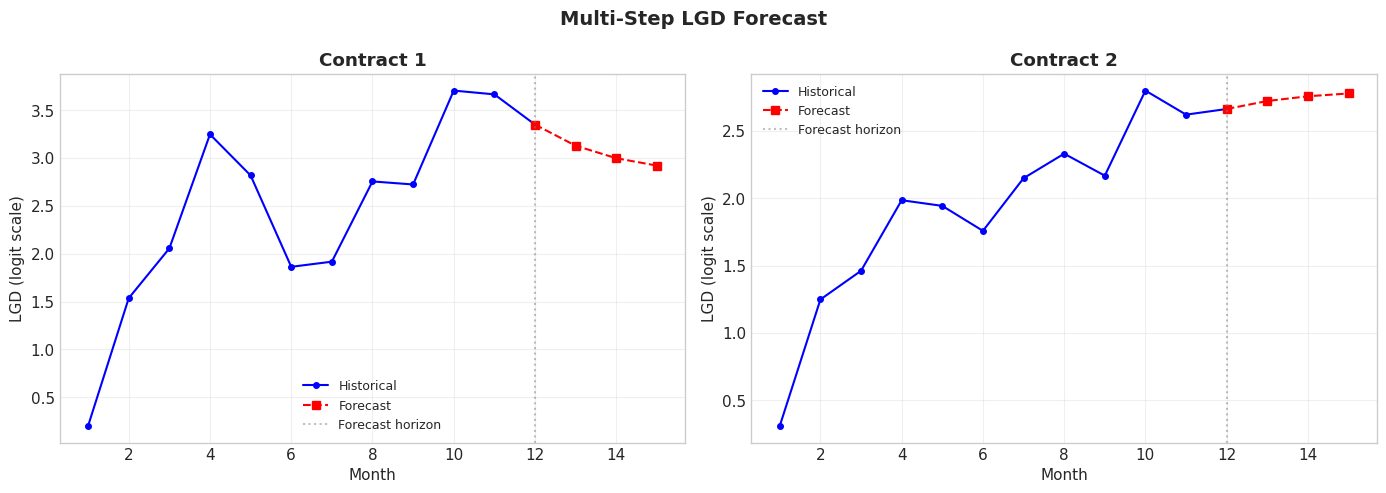

Figure saved.


In [15]:
# Visualize forecast trajectory for 2 contracts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, contract in enumerate(list(forecast_contracts)[:2]):
    ax = axes[i]

    # Historical data
    hist = df_lgd_train[df_lgd_train["contract_id"] == contract]
    ax.plot(hist["month"], hist["lgd_logit"], "b-o", label="Historical", markersize=4)

    # Forecast
    fc = forecasts[forecasts["contract_id"] == contract]
    # Connect last historical point to forecast
    connect_months = [hist["month"].iloc[-1], *list(fc["month"])]
    connect_vals = [hist["lgd_logit"].iloc[-1], *list(fc["forecast"])]
    ax.plot(connect_months, connect_vals, "r--s", label="Forecast", markersize=6)

    ax.axvline(x=12, color="gray", linestyle=":", alpha=0.5, label="Forecast horizon")
    ax.set_xlabel("Month")
    ax.set_ylabel("LGD (logit scale)")
    ax.set_title(f"Contract {contract}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Multi-Step LGD Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_forecast_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

### 3.4 GMM Validation

In [16]:
# Validate GMM-specific diagnostics
gmm_validation = lgd_pipeline.validate()

print(f"Overall: {'PASS' if gmm_validation['passed'] else 'FAIL'}")
print()
for check in gmm_validation["checks"]:
    status = "PASS" if check["passed"] else "FAIL"
    print(f"  [{status}] {check['name']}")

if gmm_validation["warnings"]:
    print()
    print("Warnings:")
    for w in gmm_validation["warnings"]:
        print(f"  - {w}")

# Show test statistics
print()
print("GMM Diagnostics:")
print(f"  Hansen J p-value: {lgd_pipeline.results.hansen_j.pvalue:.4f}")
print(f"  AR(2) p-value:    {lgd_pipeline.results.ar2_test.pvalue:.4f}")

Overall: PASS

  [PASS] has_params
  [PASS] no_nan_params
  [PASS] hansen_j_valid
  [PASS] ar2_valid
  [PASS] instrument_ratio_ok

GMM Diagnostics:
  Hansen J p-value: 0.1227
  AR(2) p-value:    0.1138


---

## Section 4: Refit and Compare

In production, models are periodically re-estimated as new data arrives. The key questions are:

1. **Have the coefficients changed significantly?** (parameter drift)
2. **Is the new model still valid?** (diagnostic checks)
3. **Should we update the production model?** (comparison)

The `refit()` method re-estimates the model with new data, and `compare()` creates a drift report.

### 4.1 Save a Copy of the Current Model

In [17]:
# Save the current (v1) pipeline before refitting
lgd_pipeline_v1 = PanelPipeline(
    model_class=DifferenceGMM,
    model_params=lgd_pipeline.model_params.copy(),
    name="LGD Model v1 (baseline)",
)
lgd_pipeline_v1.fit(df_lgd_train)

print("v1 coefficients:")
print(lgd_pipeline_v1.results.params)
print(f"\nv1 observations: {lgd_pipeline_v1.results.nobs}")

v1 coefficients:
L1.lgd_logit        0.5913
saldo_real          0.1109
pib_growth          0.0456
selic              -0.0094
collateral_ratio    0.0820
dtype: float64

v1 observations: 2000


### 4.2 Refit with Updated Data

In [18]:
# New data arrives — use all 15 months
df_updated = df_lgd.copy()  # months 1-15
print(
    f"Updated data: {df_updated.shape[0]} obs, months {df_updated['month'].min()}-{df_updated['month'].max()}"
)

# Create v2 pipeline and fit with updated data
lgd_pipeline_v2 = PanelPipeline(
    model_class=DifferenceGMM,
    model_params=lgd_pipeline.model_params.copy(),
    name="LGD Model v2",
)
lgd_pipeline_v2.fit(df_updated)

print(f"\nv2 observations: {lgd_pipeline_v2.results.nobs}")
print("\nv2 coefficients:")
print(lgd_pipeline_v2.results.params)

Updated data: 3000 obs, months 1-15



v2 observations: 2600

v2 coefficients:
L1.lgd_logit        0.5336
saldo_real          0.1009
pib_growth          0.0441
selic              -0.0098
collateral_ratio    0.0941
dtype: float64


### 4.3 Compare Versions

In [19]:
# Compare v1 vs v2
comparison = lgd_pipeline_v2.compare(lgd_pipeline_v1)

print("Parameter Drift Report (v2 vs v1):")
print("=" * 65)
display(comparison.round(4))

Parameter Drift Report (v2 vs v1):


,current,previous,diff,pct_change
L1.lgd_logit,0.5336,0.5913,-0.0577,-9.7595
saldo_real,0.1009,0.1109,-0.0101,-9.0894
pib_growth,0.0441,0.0456,-0.0014,-3.1720
selic,-0.0098,-0.0094,-0.0004,-4.5656
collateral_ratio,0.0941,0.0820,0.0121,14.7192


In [20]:
# Identify significant drift (>10% change)
print("Parameters with >10% change:")
significant_drift = comparison[comparison["pct_change"].abs() > 10]
if len(significant_drift) > 0:
    display(significant_drift.round(4))
else:
    print("  No parameters with >10% drift.")

Parameters with >10% change:


,current,previous,diff,pct_change
collateral_ratio,0.0941,0.082,0.0121,14.7192


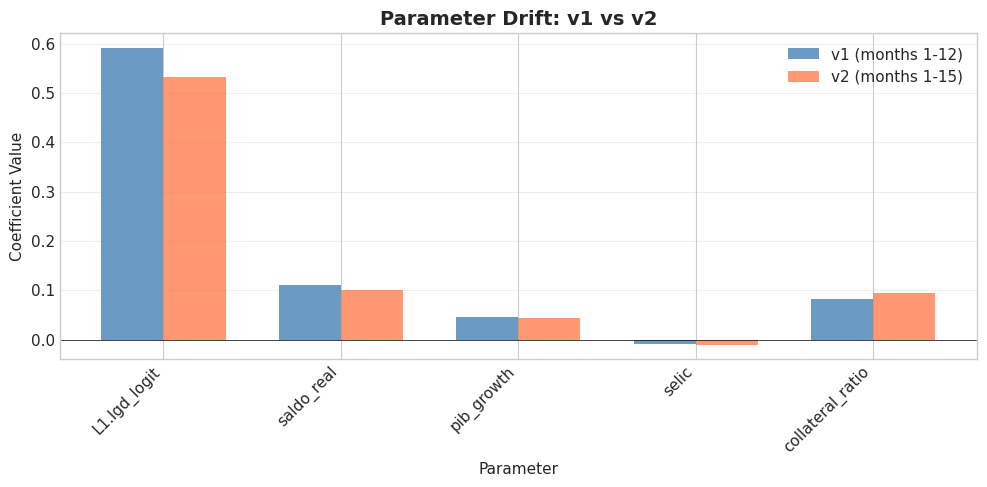

Figure saved.


In [21]:
# Visualize parameter drift
fig, ax = plt.subplots(figsize=(10, 5))

params = comparison.index
x = np.arange(len(params))
width = 0.35

ax.bar(
    x - width / 2,
    comparison["previous"],
    width,
    label="v1 (months 1-12)",
    color="steelblue",
    alpha=0.8,
)
ax.bar(
    x + width / 2, comparison["current"], width, label="v2 (months 1-15)", color="coral", alpha=0.8
)

ax.set_xlabel("Parameter")
ax.set_ylabel("Coefficient Value")
ax.set_title("Parameter Drift: v1 vs v2", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(params, rotation=45, ha="right")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_parameter_drift.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

### 4.4 Using `refit()` Directly

The `refit()` method re-estimates in place and logs a comparison warning if large changes are detected.

In [22]:
# Demonstrate refit() — mutates the pipeline in-place
refit_pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params=lgd_pipeline.model_params.copy(),
    name="LGD Refit Demo",
)
refit_pipeline.fit(df_lgd_train)
print("Before refit:")
print(f"  Timestamp: {refit_pipeline.fit_timestamp}")
print(f"  L1.lgd_logit = {refit_pipeline.results.params['L1.lgd_logit']:.4f}")

# Refit with more data
refit_pipeline.refit(df_lgd)
print("\nAfter refit:")
print(f"  Timestamp: {refit_pipeline.fit_timestamp}")
print(f"  L1.lgd_logit = {refit_pipeline.results.params['L1.lgd_logit']:.4f}")

Before refit:
  Timestamp: 2026-02-22T15:37:51.301744
  L1.lgd_logit = 0.5913



After refit:
  Timestamp: 2026-02-22T15:37:51.610167
  L1.lgd_logit = 0.5336


---

## Section 5: Export and Documentation

For production deployment, you often need to:
- Export the model configuration as a dictionary or JSON
- Generate a summary for stakeholders
- Document the model specification in APIs or configuration management systems

### 5.1 Export as Dictionary

In [23]:
# Export pipeline config
config = lgd_pipeline.to_dict()

print("Pipeline configuration keys:")
for key in config:
    value = config[key]
    if isinstance(value, dict):
        print(f"  {key}: {{...}} ({len(value)} items)")
    else:
        print(f"  {key}: {value}")

Pipeline configuration keys:
  name: LGD Model v1
  description: Arellano-Bond GMM for Loss Given Default estimation
  model_class: DifferenceGMM
  model_params: {...} (10 items)
  fit_timestamp: 2026-02-22T15:37:49.689001
  panelbox_version: 1.0.0
  params: {...} (5 items)
  std_errors: {...} (5 items)


### 5.2 Export as JSON

In [24]:
# Export to JSON file
json_path = MODELS_DIR / "lgd_config.json"
json_str = lgd_pipeline.to_json(json_path)

print(f"JSON saved to: {json_path}")
print(f"JSON size: {len(json_str)} characters")
print()
print("JSON content (first 500 chars):")
print(json_str[:500])

JSON saved to: ../outputs/models/lgd_config.json
JSON size: 994 characters

JSON content (first 500 chars):
{
  "name": "LGD Model v1",
  "description": "Arellano-Bond GMM for Loss Given Default estimation",
  "model_class": "DifferenceGMM",
  "model_params": {
    "dep_var": "lgd_logit",
    "lags": 1,
    "exog_vars": [
      "saldo_real",
      "pib_growth",
      "selic",
      "collateral_ratio"
    ],
    "id_var": "contract_id",
    "time_var": "month",
    "gmm_max_lag": 3,
    "collapse": true,
    "two_step": true,
    "robust": true,
    "time_dummies": false
  },
  "fit_timestamp": "2026-0


### 5.3 Summary for Stakeholders

In [25]:
# Generate a formatted summary
print("=== Model Card ===")
print(lgd_pipeline.summary())
print()

# Detailed model results
print("=== Detailed Results ===")
print(lgd_pipeline.results.summary())

=== Model Card ===
PanelPipeline: LGD Model v1
  Model: DifferenceGMM
  Fitted: 2026-02-22T15:37:49.689001
  Version: 1.0.0
  Observations: 2000
  Parameters: 5

=== Detailed Results ===
                                Difference GMM                                
Number of observations:          2,000
Number of groups:                  200
Number of instruments:               6
Instrument ratio:                0.030
GMM type:                   Two-step (Windmeijer)
------------------------------------------------------------------------------
Variable                    Coef.     Std.Err.        z    P>|z|     [95% Conf. Int.]
------------------------------------------------------------------------------
L1.lgd_logit             0.591334     0.025741    22.97   0.0000 [ 0.540883,  0.641784] ***
saldo_real               0.110943     0.026693     4.16   0.0000 [ 0.058625,  0.163261] ***
pib_growth               0.045573     0.003424    13.31   0.0000 [ 0.038861,  0.052285] ***
selic   

---

## Section 6: Best Practices

### Production Pipeline Checklist

1. **Always validate before deploying** — use `pipeline.validate()` and check GMM diagnostics
2. **Keep pipeline names descriptive** — include model type, version, and date
3. **Log every refit with comparison metrics** — track coefficient drift over time
4. **Set up monitoring** — check prediction quality degradation
5. **Version your pipelines** — use `ModelRegistry` (covered in Notebook 05)

### Common Pitfalls

| Pitfall | Solution |
|---------|----------|
| NaN predictions in GMM | First obs per entity has no lag — expected behavior |
| Hansen J = NaN | Too many instruments with `collapse=True` + `time_dummies=True`; use `time_dummies=False` |
| Large parameter drift | Investigate data quality; consider longer training windows |
| Forecast divergence | AR coefficient close to 1.0 causes explosive forecasts; check stationarity |

---

## Exercises

### Exercise 1 (Easy): PooledOLS Pipeline

Create a pipeline using `PooledOLS` for the firm panel data.

1. Create a `PanelPipeline` with `PooledOLS` and formula `investment ~ value + capital + sales`
2. Fit on `df_firms`
3. Predict on `df_new_firms`
4. Save the pipeline, then load it and verify predictions match

In [26]:
# Exercise 1: Your code here


### Exercise 2 (Medium): Collapsed vs Non-Collapsed GMM

Create two GMM pipelines for the bank LGD data (training on months 1-12):
- Pipeline A: `collapse=True`
- Pipeline B: `collapse=False`

Compare their predictions on the test data (months 13-15). Which is more stable? Use both `predict()` and `compare()` to analyze differences.

In [27]:
# Exercise 2: Your code here


### Exercise 3 (Medium): Monthly Refit Loop

Implement a `monthly_refit_loop(pipeline, monthly_data_list)` function that:
1. Takes a pipeline and a list of DataFrames (one per month of cumulative data)
2. Refits the pipeline each month
3. Tracks how each coefficient evolves over time
4. Returns a DataFrame with coefficient trajectories

Use the bank LGD data, splitting into cumulative windows: months 1-4, 1-5, ..., 1-15.

Plot the coefficient trajectories.

In [28]:
# Exercise 3: Your code here


### Exercise 4 (Hard): Complete Production Workflow

Build a complete production workflow for the bank LGD data:

1. Split `bank_lgd` by time: train (months 1-12), test (months 13-15)
2. Estimate 3 models: `PooledOLS`, `FixedEffects`, `DifferenceGMM`
3. Create a `PanelPipeline` for each
4. Predict on test data
5. Create a comparison table with RMSE, MAE, and direction accuracy
6. Select the best model and save it as the production model

**Hints**:
- For static models, use the formula `lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio`
- Direction accuracy = fraction of predictions that correctly predict the sign of the change

In [29]:
# Exercise 4: Your code here


---

## Summary

In this notebook, we learned:

- **`PanelPipeline`** provides a unified interface for the full model lifecycle
- **Static models** (PooledOLS, FixedEffects) use `fit()` and `predict()`
- **GMM models** additionally support `forecast()` for multi-step predictions
- **`refit()`** re-estimates with new data, and **`compare()`** detects parameter drift
- **`to_dict()`** and **`to_json()`** export configurations for documentation
- Always **validate** before deploying and **monitor** for drift

### Next Steps

- **Notebook 04**: Model Validation (`ModelValidator`) for comprehensive pre-deployment checks
- **Notebook 05**: Model Registry (`ModelRegistry`) for versioning and lifecycle management